In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [6]:
verbose=False
force=False

method='deseq2'
imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

exclude_prog_list=['CCLE']

dfn_tumor, dfn_normal, df_gtex, df_ana = gdc.get_all_data_from_disease(disease_id=DISEASE_ID, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

df_ana



>> dfn_tumor (60616, 460)
>> dfn_normal (60616, 103)


,prog_id,psi_id,disease_id,primary_site
0,CPTAC,PAAD,PAAD,Pancreas
1,CPTAC,PAAD_GDC,PAAD,Pancreas
2,TCGA,TCGA-PAAD,PAAD,Pancreas


In [7]:
dfn_tumor.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,448,449,450,451,452,453,454,455,456,457
0,ENSG00000000003,TSPAN6,protein_coding,18,0,6,2,7,0,4,...,1060,1221,210,18,155,36,84,182,323,192
1,ENSG00000000005,TNMD,protein_coding,39,23,3,15,13,13,10,...,0,1,87,4,2,0,1,8,1,0
2,ENSG00000000419,DPM1,protein_coding,48,11,13,5,27,5,5,...,1056,843,474,711,493,744,528,457,447,524


In [8]:
dfn_normal.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100
0,ENSG00000000003,TSPAN6,protein_coding,1,1,0,1,0,2,1,...,0,0,1,1,1,1,0,2,0,0
1,ENSG00000000005,TNMD,protein_coding,7,10,14,3,7,14,5,...,11,13,3,9,16,12,17,9,7,9
2,ENSG00000000419,DPM1,protein_coding,6,3,2,2,0,6,8,...,11,4,6,9,7,5,15,5,1,9


### Clusterization

In [9]:
group = 'Normal'
group = 'Tumor'

verbose=False
force=False

disease_id=DISEASE_ID
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
min_clusters = 6; max_clusters = 12
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05
perc_min_samples=0.25; top_n=10_000

if group == 'Tumor':
    df = dfn_tumor
    n_clusters = 10
else:
    df = dfn_normal
    n_clusters = 3


df_cluster, df_sel, df_cpm, df_pca, df_umap = gdc.cluster_expression_data_group(df, group=group, n_clusters=n_clusters, 
                                                n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                method_hca=method_hca, hca_criterion=hca_criterion,
                                                LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                perc_min_samples=perc_min_samples, top_n=top_n,
                                                force=force, verbose=verbose)

In [10]:
gdc.df_pca

,PC1,PC2,PC3
0,4.495,63.019,-12.462
1,-36.287,22.011,-46.591
2,24.080,62.072,-13.044
3,-33.386,10.940,-38.871
4,42.726,73.060,-6.632
...,...,...,...
452,183.138,-61.941,-23.981
453,185.864,-62.813,-21.492
454,182.858,-65.070,-25.529
455,188.104,-64.790,-14.608


### Best cluster number

In [11]:
gdc.df_samp_clusters

,sample,cluster
0,0,3
1,1,4
2,2,3
3,3,4
4,4,3
...,...,...
452,452,2
453,453,2
454,454,2
455,455,2


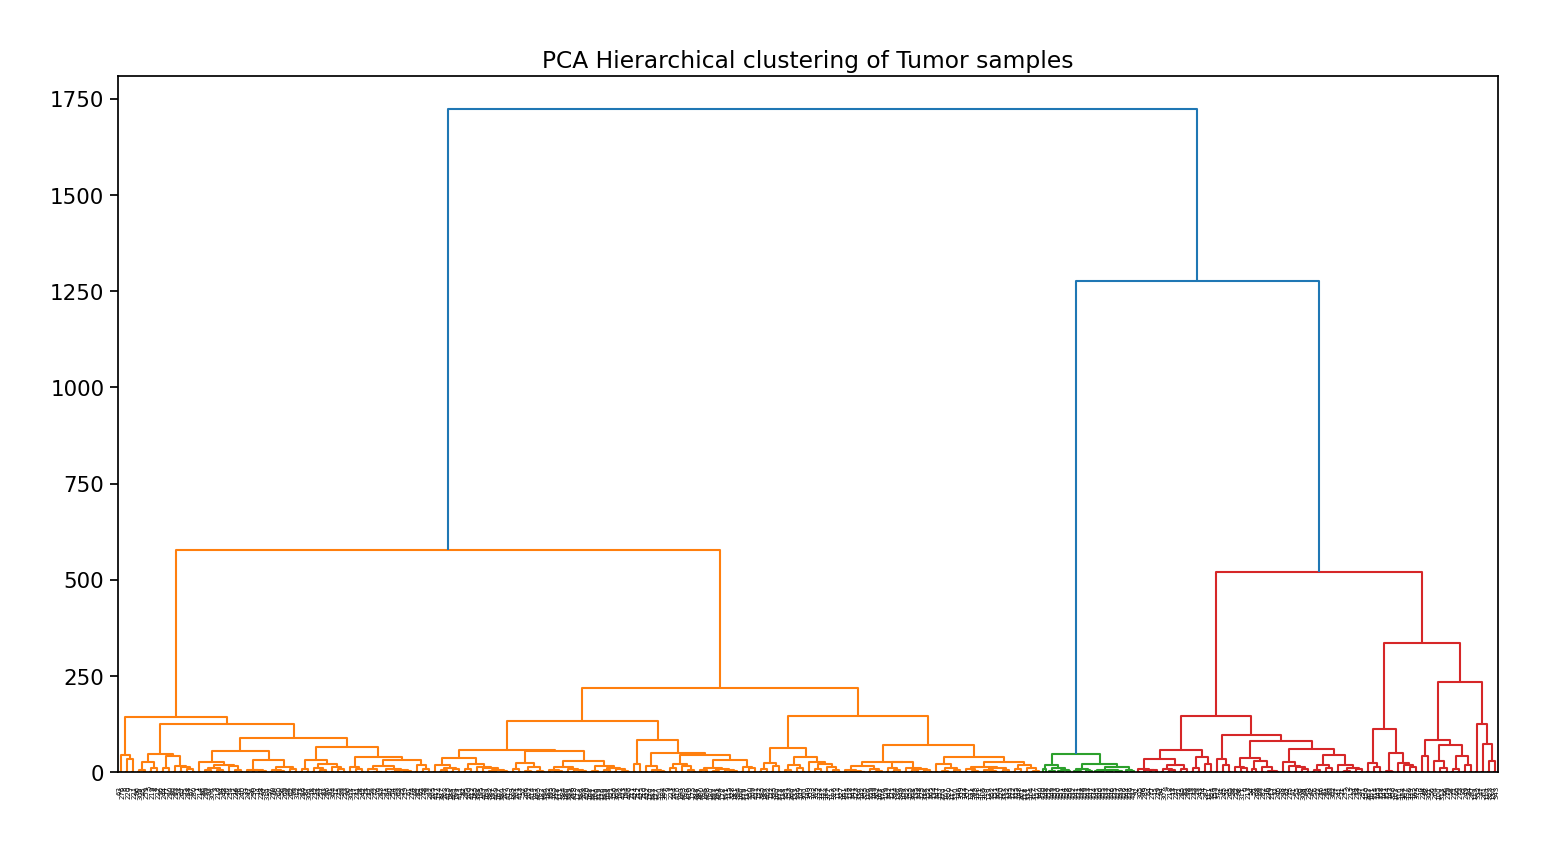

In [12]:
gdc.plot_HCA_PCA(df_pca, figsize=(15,8))

### Loop over chosen number of clusters

In [13]:
### HCA from PCA
gdc.df_hca.cluster.max()

10

In [14]:
gdc.df_hca.head(5)

,sample,cluster
0,1,7
1,2,1
2,3,7
3,4,1
4,5,6


In [15]:
df_all_sign = gdc.df_all_sign

df_all_sign.head(2)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621


In [16]:
df_sig_sign = gdc.df_sig_sign

df_sig_sign.head(2)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000230535,1,104,353,9.564,3.275,6.289,9.965e-69,1.050e-65,BASP1P1
1,ENSG00000262619,1,104,353,11.497,5.285,6.212,6.212e-62,3.658e-59,LINC00621


In [17]:
cluster_list = np.unique(gdc.df_hca.cluster)
cluster_list

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [18]:
verbose=False
force=False

case = case_list[0]
print(f"case = {case}")

df_hca = gdc.df_hca

for nclu in cluster_list:

    sample_cols = df_hca[df_hca.cluster == nclu]['sample'].to_list()
    print(f"Cluster {nclu}: {len(sample_cols)} samples -> {sample_cols}\n")

    break

 

print("\n--------------- end ---------------")



case = Tumor
Cluster 1: 104 samples -> [2, 4, 6, 7, 8, 9, 12, 13, 15, 18, 19, 21, 24, 26, 27, 29, 31, 34, 35, 37, 40, 41, 44, 46, 47, 49, 50, 54, 57, 58, 60, 62, 64, 66, 68, 69, 71, 72, 74, 76, 78, 80, 81, 84, 87, 88, 91, 92, 94, 97, 98, 100, 215, 217, 220, 221, 222, 223, 226, 227, 229, 232, 233, 235, 238, 240, 241, 243, 245, 248, 249, 251, 254, 255, 258, 260, 261, 263, 264, 268, 270, 271, 273, 275, 277, 279, 281, 282, 284, 285, 287, 289, 291, 293, 294, 297, 300, 301, 304, 305, 307, 310, 311, 313]


--------------- end ---------------


In [19]:
dfn_tumor.head(2)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,448,449,450,451,452,453,454,455,456,457
0,ENSG00000000003,TSPAN6,protein_coding,18,0,6,2,7,0,4,...,1060,1221,210,18,155,36,84,182,323,192
1,ENSG00000000005,TNMD,protein_coding,39,23,3,15,13,13,10,...,0,1,87,4,2,0,1,8,1,0


In [20]:
cols = ['geneid', 'symbol', 'biotype']
sel_cols = cols + [str(x) for x in sample_cols]
dfn_tumor2 = dfn_tumor[sel_cols]
dfn_tumor2.head(3)


,geneid,symbol,biotype,2,4,6,7,8,9,12,...,294,297,300,301,304,305,307,310,311,313
0,ENSG00000000003,TSPAN6,protein_coding,0,2,0,4,2,2,0,...,1,0,5,0,0,0,4,0,0,3
1,ENSG00000000005,TNMD,protein_coding,23,15,13,10,17,17,52,...,11,24,71,14,35,14,62,2,31,14
2,ENSG00000000419,DPM1,protein_coding,11,5,5,5,13,23,15,...,5,8,12,17,8,12,1,6,14,3


In [23]:
df_gtex.head(2)

,ensemblid,symbol,GTEX-1JMLX-1726-SM-HL9TG,GTEX-15ER7-1326-SM-6LPK9,GTEX-11EQ9-1026-SM-5H134,GTEX-1B996-1326-SM-731EO,GTEX-11GSP-0426-SM-5A5KX,GTEX-11ONC-0526-SM-5BC57,GTEX-1IL2U-2326-SM-CNNQV,GTEX-15DYW-1626-SM-6LLI1,GTEX-13O1R-1826-SM-5KM3B,GTEX-S33H-1226-SM-4AD69,GTEX-1B933-1726-SM-731FC,GTEX-18A7A-1726-SM-7LT93,GTEX-14PJM-2126-SM-6AJAS,GTEX-14C39-1026-SM-5P9IG,GTEX-18A6Q-1726-SM-7LT9A
0,ENSG00000290825.2,DDX11L16,0,0,1,1,1,0,1,1,0,0,1,0,0,0,1
1,ENSG00000223972.6,DDX11L1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
PROG_ID, PSI_ID, nclu, gdc.prog_id, gdc.psi_id

('TCGA', 'TCGA-PAAD', 1, '', '')

In [27]:
force=False
verbose=True

df_lfc, df_lfc_ori, degs_txt, msg = gdc.calc_degs(
                                        prog_id = PROG_ID, 
                                        psi_id = PSI_ID,
                                        ncluster = nclu,
                                        df_tumor = dfn_tumor2,
                                        df_normal = dfn_normal, 
                                        df_gtex_ctrl = df_gtex,
                                        root_src = gdc.root_src,
                                        run_conda = True,
                                        lfc_cutoff = 1.0,
                                        fdr_cutoff = 0.05,
                                        method = method,
                                        force = force,
                                        verbose = verbose,
                                        )



Table opened ((89, 12)) at '/home/flavio/uv/perturb_agent/data/gdc_to_cbioportal_study_mapping.tsv'


/home/flavio/uv/perturb_agent/notebooks/../src/libs/calc_degs_lib.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["_total_reads"] = df2[count_cols].sum(axis=1)
/home/flavio/uv/perturb_agent/notebooks/../src/libs/calc_degs_lib.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["_total_reads"] = df2[count_cols].sum(axis=1)


>>> LFC calc with deseq2 - running inside conda environment.
